In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
pTrue = 0.001

In [3]:
f = open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230823_IQAE/results_IQAE_pTrue0001_epsilon0001_alphaTot005.dat","rb")
results = pickle.load(f)

In [5]:
results[0]

{'Estimate': 0.0009493662636231631,
 'TotalOracleCalls': 3645,
 'nGrover': [0, 1, 3, 7, 15],
 'nShots': [62, 34, 37, 159, 27],
 'n1s': [0, 0, 2, 44, 18],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.0, 0.5212457687788165],
  [0.0, 0.2233745560418127],
  [0.0005521239061016787, 0.10448748751590042],
  [0.02423203661893798, 0.05057074189202233],
  [0.015615822093554771, 0.044162360144484145]],
 'ampSqIntervals': [[0, 1],
  [0.0, 0.2479650121560565],
  [0.0, 0.04907181700997086],
  [3.0484077671300394e-07, 0.010877961253954533],
  [0.0005870766763748731, 0.002555220580614762],
  [0.00024383407872722513, 0.001949046474891978]]}

In [6]:
errors = [r["Estimate"] - pTrue for r in results]

In [7]:
np.mean(errors)

1.1808182208720516e-05

In [8]:
nGroverLastVals, countNGroverLast = np.unique([r["nGrover"][-1] for r in results], return_counts=True)
print(nGroverLastVals)
print(countNGroverLast)

[15 27 28 29 30]
[9957    1    5   12   25]


In [17]:
nShotsLast = [r["nShots"][-1] for r in results]
nShotsLastVals, countNShotsLast = np.unique(nShotsLast, return_counts=True)
dfnShotsLast = pd.DataFrame({"nShotsLast": nShotsLastVals, "count": countNShotsLast})
print(dfnShotsLast)

    nShotsLast  count
0            9      1
1           10      6
2           11     14
3           12      9
4           13      1
5           14      7
6           16      3
7           18      2
8           21     44
9           22     24
10          23     45
11          24    270
12          25    808
13          26    708
14          27   3731
15          28   4215
16          29     24
17          30     13
18          31     13
19          32     16
20          33     10
21          34      5
22          35      6
23          36      5
24          37      2
25          38     16
26          40      1
27          41      1


In [17]:
from IQAEUtil import Bias

In [19]:
finalGroverNum = 15
aveNShotLast = np.mean(nShotsLast)
print(aveNShotLast)
biasTheo = Bias(pTrue, finalGroverNum, aveNShotLast)
print(biasTheo)

27.0512
1.7347179340074646e-05


bias理論値とerror平均値合わず...

In [20]:
p1Last = [r["n1s"][-1] / r["nShots"][-1] for r in results]

(array([  44.,  115.,  378., 1329., 2775., 2112., 2068., 1064.,  107.,
           8.]),
 array([0.33333333, 0.4       , 0.46666667, 0.53333333, 0.6       ,
        0.66666667, 0.73333333, 0.8       , 0.86666667, 0.93333333,
        1.        ]),
 <BarContainer object of 10 artists>)

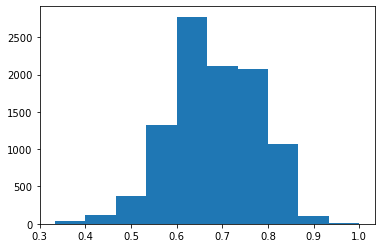

In [21]:
plt.hist(p1Last)

In [25]:
errors_nGroverLast15 = []
for r in results:
    if r["nGrover"][-1] == 15:
        errors_nGroverLast15.append(r["Estimate"] - pTrue)

In [26]:
np.mean(errors_nGroverLast15)

1.1870419485302986e-05

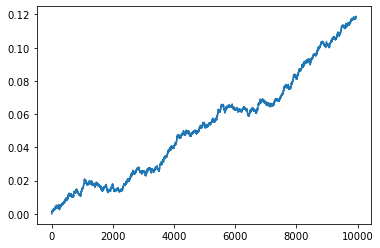

In [27]:
ax = plt.gca()
plt.plot(np.array(errors_nGroverLast15).cumsum())
plt.show()

In [26]:
print(np.sum(errors_nGroverLast128))
print(np.std(errors_nGroverLast128) * np.sqrt(len(errors_nGroverLast128)))

0.0031957080353907513
0.006799028248676289


ショット数少なくて、biasとしてテイラー展開の2次より後の項も効いているのか？
ショット数を大きくして試してみる

In [4]:
nShotMax = [np.max(r["nShots"]) for r in results]

(array([3941., 1751., 1429.,  990.,  757.,  464.,  282.,  183.,  108.,
          95.]),
 array([ 62. ,  73.3,  84.6,  95.9, 107.2, 118.5, 129.8, 141.1, 152.4,
        163.7, 175. ]),
 <BarContainer object of 10 artists>)

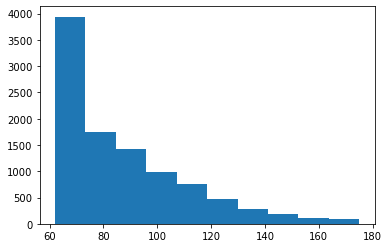

In [5]:
plt.hist(nShotMax)

In [7]:
from IQAEBinom import IQAEBinom

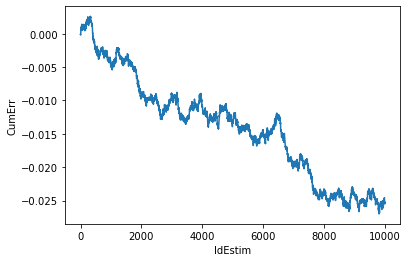

In [10]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05 / nEstim
minRatio = 2
pTrue = 0.001
errors_pTrue001_nShot200 = []
results_pTrue001_nShot200 = []
for i in range(nEstim):
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit=200, confint_method="beta", minRatio=minRatio)
    results_pTrue001_nShot200.append(result)
    errors_pTrue001_nShot200.append(result['Estimate'] - pTrue)

plt.xlabel('IdEstim')
plt.ylabel('CumErr')
ax = plt.gca()
plt.plot(np.arange(nEstim), np.array(errors_pTrue001_nShot200).cumsum())
plt.show()

In [11]:
results_pTrue001_nShot200[0]

{'Estimate': 0.0008955547713601041,
 'TotalOracleCalls': 5000,
 'nGrover': [0, 2, 9],
 'nShots': [200, 200, 200],
 'n1s': [0, 5, 58],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.0, 0.31337463833115664],
  [0.003677928234737301, 0.07808560636957408],
  [0.020269810810629778, 0.04022069839891576]],
 'ampSqIntervals': [[0, 1],
  [0.0, 0.09503080886908205],
  [1.3527095105337132e-05, 0.006084979385209362],
  [0.00041080896330206634, 0.001616832445127139]]}

In [20]:
print(np.sum(errors_pTrue001_nShot200))
print(np.std(errors_pTrue001_nShot200) * np.sqrt(len(errors_pTrue001_nShot200)))

-0.025291966865784596
0.011223457467714765


In [13]:
nGroverLastVals_nShot200, countNGroverLast_nShot200 = np.unique([r["nGrover"][-1] for r in results_pTrue001_nShot200], return_counts=True)
print(nGroverLastVals_nShot200)
print(countNGroverLast_nShot200)

[ 6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[   2  121 1866 4154 1849  276   58   56  259  549  546  237   23    4]


In [14]:
results_pTrue001_nShot200_nGroverLast9 = []
for r in results_pTrue001_nShot200:
    if r["nGrover"][-1] == 9:
        results_pTrue001_nShot200_nGroverLast9.append(r)

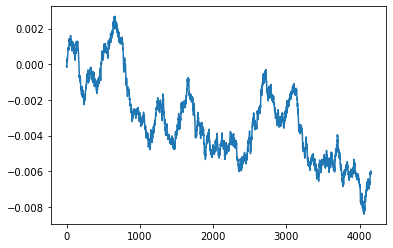

In [15]:
errors_pTrue001_nShot200_nGroverLast9 = [r["Estimate"] - pTrue for r in results_pTrue001_nShot200_nGroverLast9]
ax = plt.gca()
plt.plot(np.arange(len(results_pTrue001_nShot200_nGroverLast9)), np.array(errors_pTrue001_nShot200_nGroverLast9).cumsum())
plt.show()

In [18]:
biasTheo = Bias(pTrue, 9, 200)
print(biasTheo)

1.8477443073118951e-06


In [19]:
np.mean(errors_pTrue001_nShot200_nGroverLast9)

-1.4599649791041695e-06

ショット数少ないとbiasの高次項効くし、ショット数多いとbias << variance...